In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


In [3]:
df = pd.read_excel("./Concrete_Data.xls")
df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


# Proof or Standardization
Prior to modeling, we applied standardization. Standardization transforms features to have mean = 0 and standard deviation = 1, putting all features on the same scale so they’re treated fairly by machine learning algorithms. We do that because to put all features on the same scale.

In [4]:
df_clean = df.copy()
df_features = df_clean.iloc[:, 0:8]
df_output = df_clean.iloc[:, -1:]

scaler = StandardScaler()
normalized_df = scaler.fit_transform(df_features)

norm_df = pd.DataFrame(normalized_df, columns=df_features.columns, index=df_features.index)
norm_df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
0,2.477918,-0.856886,-0.847132,-0.916663,-0.620225,0.863160,-1.217658,-0.279733
1,2.477918,-0.856886,-0.847132,-0.916663,-0.620225,1.056170,-1.217658,-0.279733
2,0.491443,0.795533,-0.847132,2.175367,-1.038944,-0.526514,-2.240913,3.553066
3,0.491443,0.795533,-0.847132,2.175367,-1.038944,-0.526514,-2.240913,5.057677
4,-0.790432,0.678414,-0.847132,0.488805,-1.038944,0.070531,0.647908,4.978487
...,...,...,...,...,...,...,...,...
1025,-0.045623,0.488241,0.564569,-0.092122,0.451695,-1.323003,-0.065874,-0.279733
1026,0.392837,-0.856886,0.960095,0.676201,0.702927,-1.994679,0.496916,-0.279733
1027,-1.270057,0.759585,0.850661,0.521599,-0.017270,-1.036061,0.080127,-0.279733
1028,-1.168580,1.308072,-0.847132,-0.279518,0.853666,0.214646,0.191188,-0.279733


In [5]:
summary = norm_df.describe().T[["mean"]]
summary["std"] = norm_df.std()
summary

,mean,std
Cement (component 1)(kg in a m^3 mixture),9.657862e-17,1.000486
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0.000000e+00,1.000486
Fly Ash (component 3)(kg in a m^3 mixture),2.759389e-17,1.000486
Water (component 4)(kg in a m^3 mixture),3.587206e-16,1.000486
Superplasticizer (component 5)(kg in a m^3 mixture),-2.759389e-17,1.000486
Coarse Aggregate (component 6)(kg in a m^3 mixture),2.276496e-16,1.000486
Fine Aggregate (component 7)(kg in a m^3 mixture),-1.931572e-16,1.000486
Age (day),2.069542e-17,1.000486


# Regularization and Cross Validation

In [6]:
#--Lambda candidates--
lambda_candidates = np.logspace(-3, 3, 20)
# [0.001, 0.002, ..., 0.1, ..., 10, ..., 1000]
lambda_candidates

array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
       1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
       3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
       6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
       1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03])

## Finding Lambda with Cross Validation with K = 10

In [7]:
K = 10  # Number of folds
kfold = KFold(n_splits=K, shuffle=True, random_state=42)

cv_errors = []
for lam in lambda_candidates:
    ridge = Ridge(alpha=lam)
    ridge_fold_errors = []
    for train_index, test_index in kfold.split(norm_df):
        X_train, X_test = norm_df.iloc[train_index], norm_df.iloc[test_index]
        y_train, y_test = df_output.iloc[train_index], df_output.iloc[test_index]

        ridge.fit(X_train, y_train)
        # Predict on validation set
        y_pred = ridge.predict(X_test)

        # Calculate MSE
        mse = mean_squared_error(y_test, y_pred)
        ridge_fold_errors.append(mse)

    avg_cv_error = np.mean(ridge_fold_errors)
    cv_errors.append(avg_cv_error)
    print(f"λ = {lam:8.4f} → CV Error (MSE) = {avg_cv_error:8.2f}")

cv_errors = np.array(cv_errors)

# Find best lambda
best_idx = np.argmin(cv_errors)
best_lambda = lambda_candidates[best_idx]
best_error = cv_errors[best_idx]

print(f"\n{'='*60}")
print(f"BEST LAMBDA: {best_lambda:.6f}")
print(f"BEST CV ERROR (MSE): {best_error:.2f}")
print(f"{'='*60}\n")

λ =   0.0010 → CV Error (MSE) =   109.77
λ =   0.0021 → CV Error (MSE) =   109.77
λ =   0.0043 → CV Error (MSE) =   109.77
λ =   0.0089 → CV Error (MSE) =   109.77
λ =   0.0183 → CV Error (MSE) =   109.77
λ =   0.0379 → CV Error (MSE) =   109.77
λ =   0.0785 → CV Error (MSE) =   109.77
λ =   0.1624 → CV Error (MSE) =   109.77
λ =   0.3360 → CV Error (MSE) =   109.77
λ =   0.6952 → CV Error (MSE) =   109.76
λ =   1.4384 → CV Error (MSE) =   109.76
λ =   2.9764 → CV Error (MSE) =   109.77
λ =   6.1585 → CV Error (MSE) =   109.84
λ =  12.7427 → CV Error (MSE) =   110.11
λ =  26.3665 → CV Error (MSE) =   110.80
λ =  54.5559 → CV Error (MSE) =   112.24
λ = 112.8838 → CV Error (MSE) =   115.11
λ = 233.5721 → CV Error (MSE) =   121.25
λ = 483.2930 → CV Error (MSE) =   134.31
λ = 1000.0000 → CV Error (MSE) =   158.04

BEST LAMBDA: 1.438450
BEST CV ERROR (MSE): 109.76



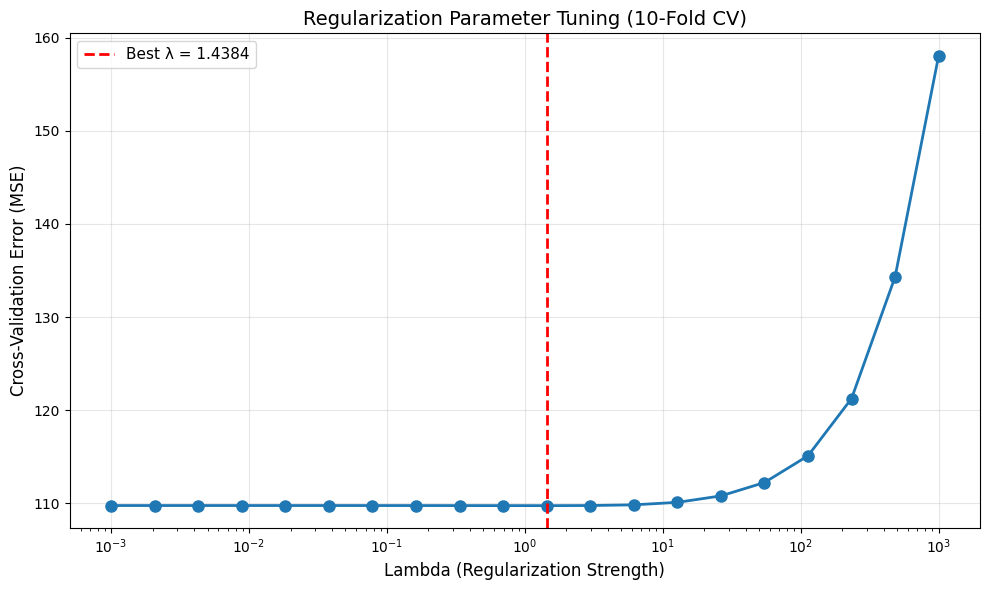

In [8]:
plt.figure(figsize=(10, 6))
plt.semilogx(lambda_candidates, cv_errors, 'o-', linewidth=2, markersize=8)
plt.axvline(best_lambda, color='r', linestyle='--', linewidth=2,
            label=f'Best λ = {best_lambda:.4f}')
plt.xlabel('Lambda (Regularization Strength)', fontsize=12)
plt.ylabel('Cross-Validation Error (MSE)', fontsize=12)
plt.title('Regularization Parameter Tuning (10-Fold CV)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('lambda_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
best_model = Ridge(alpha=best_lambda)
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

train_errors = []
test_errors = []

for train_index, test_index in kfold.split(norm_df):
    # Split data
    X_train = norm_df.iloc[train_index].values
    X_test = norm_df.iloc[test_index].values
    y_train = df_output.iloc[train_index].values.ravel()
    y_test = df_output.iloc[test_index].values.ravel()

    # Train model
    best_model.fit(X_train, y_train)

    # Predict
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Calculate MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

    print(f"Fold | Train MSE: {train_mse:8.2f} | Test MSE: {test_mse:8.2f}")

print(f"\nAverage Train MSE: {np.mean(train_errors):.2f}")
print(f"Average Test MSE:  {np.mean(test_errors):.2f}")

Fold | Train MSE:   108.02 | Test MSE:   101.22
Fold | Train MSE:   109.70 | Test MSE:    86.28
Fold | Train MSE:   104.23 | Test MSE:   135.33
Fold | Train MSE:   104.50 | Test MSE:   133.61
Fold | Train MSE:   103.67 | Test MSE:   142.39
Fold | Train MSE:   107.11 | Test MSE:   108.84
Fold | Train MSE:   109.25 | Test MSE:    90.07
Fold | Train MSE:   109.31 | Test MSE:    89.48
Fold | Train MSE:   107.61 | Test MSE:   104.86
Fold | Train MSE:   107.50 | Test MSE:   105.52

Average Train MSE: 107.09
Average Test MSE:  109.76


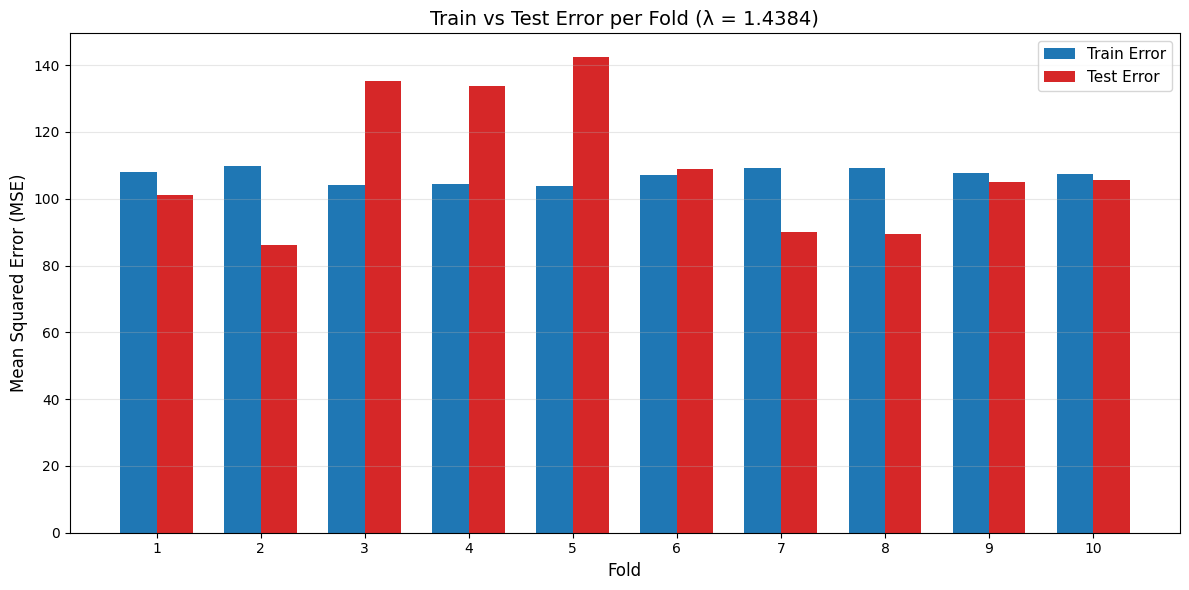


SUMMARY:
Best Lambda: 1.438450
Average CV Error (Generalization Error Estimate): 114.45 MSE
Average Train Error at Best Lambda: 107.09 MSE
Average Test Error at Best Lambda: 109.76 MSE


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
K = len(train_errors)
bar_width = 0.35
index = np.arange(K)

ax.bar(index, train_errors, bar_width, color='tab:blue', label='Train Error')
ax.bar(index + bar_width, test_errors, bar_width, color='tab:red', label='Test Error')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax.set_title(f'Train vs Test Error per Fold (λ = {best_lambda:.4f})', fontsize=14)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels([f'{i+1}' for i in range(K)])
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('2_train_vs_test_error_per_fold.png', dpi=300)
plt.show()

# Print summary
print(f"\nSUMMARY:")
print(f"Best Lambda: {best_lambda:.6f}")
print(f"Average CV Error (Generalization Error Estimate): {np.mean(cv_errors):.2f} MSE")
print(f"Average Train Error at Best Lambda: {np.mean(train_errors):.2f} MSE")
print(f"Average Test Error at Best Lambda: {np.mean(test_errors):.2f} MSE")

# Model Interpretation

In [11]:
best_model.fit(norm_df, df_output)
feature_names = norm_df.columns.tolist()
feature_names = [name.split('(')[0].strip() for name in feature_names]

w0 = best_model.intercept_.item()
weights = best_model.coef_.flatten()

print(f"Intercept (w0): {w0:.4f}")
print("\nFeature weights:")
for i, feature in enumerate(feature_names):
    print(f"w_{feature}: {weights[i]:.4f}")

Intercept (w0): 35.8178

Feature weights:
w_Cement: 12.2609
w_Blast Furnace Slag: 8.7100
w_Fly Ash: 5.4063
w_Water: -3.3755
w_Superplasticizer: 1.7392
w_Coarse Aggregate: 1.2313
w_Fine Aggregate: 1.3954
w_Age: 7.1903


In [12]:
results = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights,
    'Effect': ['Increase' if w > 0 else 'Decrease' for w in weights],
    'Magnitude': np.abs(weights)
}).sort_values('Magnitude', ascending=False)

results

,Feature,Weight,Effect,Magnitude
0,Cement,12.260882,Increase,12.260882
1,Blast Furnace Slag,8.709965,Increase,8.709965
7,Age,7.190349,Increase,7.190349
2,Fly Ash,5.406318,Increase,5.406318
3,Water,-3.375466,Decrease,3.375466
4,Superplasticizer,1.739176,Increase,1.739176
6,Fine Aggregate,1.395389,Increase,1.395389
5,Coarse Aggregate,1.231269,Increase,1.231269
